In [6]:
# import statements & checking for cuda
import torch
torch.set_float32_matmul_precision('high')
from ddpm.trainer import LitDDPM
from ddpm.unet import Unet
from helpers import first_radio_galaxy_transform_val, proj_hermitian
from torch.utils.data import DataLoader
from dataset.radio_galaxy_dataset.firstgalaxydata import FIRSTGalaxyData

import numpy as np
from ddrm.svd_replacement import Fourier2D_mask, Fourier2D_weight
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
from matplotlib.colors import LogNorm

device = torch.device('cuda')

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    print("Current device:", idx)
    print("Name:", torch.cuda.get_device_name(idx))
    x = torch.randn(1, device=f"cuda:{idx}")
    print("Tensor device:", x.device)

import os

CUDA available: True
Current device: 0
Name: NVIDIA GH200 120GB
Tensor device: cuda:0


In [7]:
# defining the model

# the image size we use will be 150x150, as set by the pre-trained DDPM
image_size = 150

# define and load the pre-trained DDPM
net = Unet(1, 32, 4, 2, 256).to('cuda')
model = LitDDPM.load_from_checkpoint('/capstor/store/cscs/ska/sk031/last-v5.ckpt', unet=net)

Channel per encoder Depth
[32, 64, 128, 256, 512]


In [82]:
# define the sampling operator used by DDRM

# sampling operator H
mask = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_uniform.npy'))
weights = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_natural.npy'))
#print(torch.min(weights[weights>0]))
weights = weights/torch.sum(weights)*torch.sum(mask)
h1 = Fourier2D_mask(channels=1, img_dim=image_size, S=mask, device=device)
h2 = Fourier2D_weight(channels=1, img_dim=image_size, S=weights, device=device)

# number of DDRM sampling steps
# increase this number to improve the image reconstruction
num_steps = 1000

# for a single input image, we will denoise batch_size times
# increase this number to get more samples
batch_size = 1

# sigma is the amount of noise added to visibility space
sigma_0 = 0.05

# the eta hyperparamt 
eta_A, eta_B, eta_C = 0.85, 1.0, 0.85

In [83]:
# for our test data we choose an out-of-domain image
# however, we need to trim/resize this down to our 150x150 input image size
test_image_file = "/capstor/scratch/cscs/etolley/3c353_gdth.fits"

from astropy.io import fits

with fits.open(test_image_file) as hdul:
    # this image is 512 x 512, rescale to 150x150
    true_image = hdul[0].data[::3,::3].astype(np.float32)
    true_image = true_image[10:-11,10:-11]
assert true_image.shape == (image_size, image_size)

#rescale the input image to go from 0 to 1
shift = np.min(true_image)
scale = np.max(true_image)
true_image = (true_image-shift)/(scale-shift)

In [84]:
# format the true image x_0
x = torch.from_numpy(true_image).reshape(1,image_size, image_size)
x_gpu = x.to(device)
x_0 = x_gpu.unsqueeze(0).repeat(batch_size, 1, 1, 1)

# define the observation y_0
y1_0 = h1.H(x_0)
y1_0 = y1_0 + sigma_0 * proj_hermitian(torch.randn_like(y1_0) * np.sqrt(2))

y2_0 = h2.H(x_0)
y2_0 = y2_0 + sigma_0 * proj_hermitian(torch.randn_like(y2_0) * np.sqrt(2))

# do the DDRM sampling
with model.ema.average_parameters():
    model.model.eval()
    x1_hat, _ = model.model.sample_ddrm_y0(
        image_size, num_steps, y1_0, x_0.shape[0], h1, sigma_0, eta_A, eta_B, eta_C
    )
    x2_hat, _ = model.model.sample_ddrm_y0(
        image_size, num_steps, y2_0, x_0.shape[0], h2, sigma_0, eta_A, eta_B, eta_C
    )

# rescale the image estimate x_hat
x1_hat = ((x1_hat[-1] + 1) / 2).clamp(0, 1)      
x2_hat = ((x2_hat[-1] + 1) / 2).clamp(0, 1)   

tensor(-0.0889) tensor(0.6398)
tensor(-0.1897) tensor(1.3781)


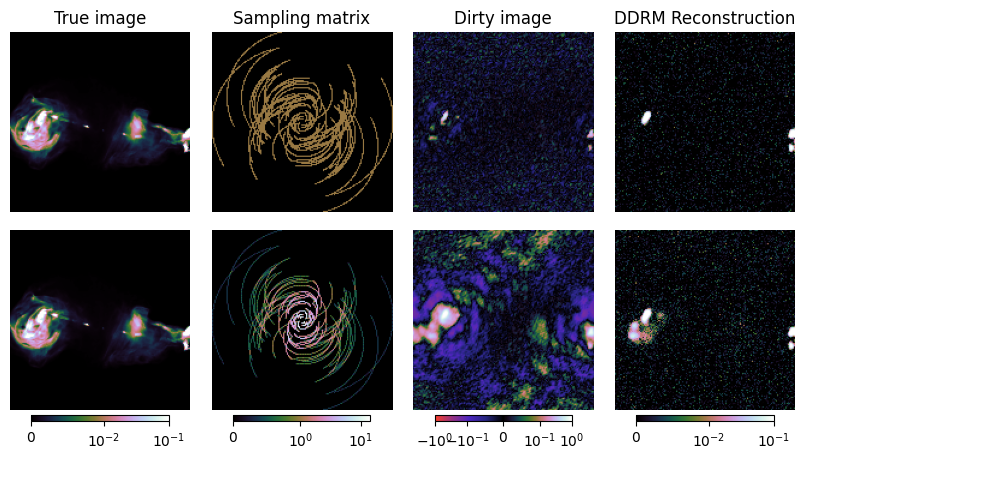

In [85]:
#make plots
fig, ax = plt.subplots(2,4+batch_size, figsize=(11, 5))
for a in ax.flatten(): a.set_axis_off()
plt.tight_layout()

x1_dirty = h1.H_pinv_nosing(y1_0).reshape(batch_size,image_size,image_size).cpu()
x2_dirty = h2.H_pinv_nosing(y2_0).reshape(batch_size,image_size,image_size).cpu()

print(torch.min(x1_dirty), torch.max(x1_dirty))
print(torch.min(x2_dirty), torch.max(x2_dirty))

# image space ---> FT ---> visibility space
def ft(img):
    return np.fft.ifftshift(np.fft.fft2(np.fft.fftshift(img)))


# visibility space ---> FT^{-1} ---> image space
def ift(img):
    return (np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(img)))).real


colors_negative = plt.cm.CMRmap_r(np.linspace(0.5, 1, 256))
colors_positive = plt.cm.cubehelix(np.linspace(0, 1, 256))
all_colors = np.vstack((colors_negative, colors_positive))
c_map = colors.LinearSegmentedColormap.from_list(
    'c_map', all_colors)

cnorm = colors.SymLogNorm(linthresh=0.01,vmin=0,vmax=.1)
dnorm = colors.SymLogNorm(linthresh=0.1,vmin=-1,vmax=1)
wnorm = colors.SymLogNorm(linthresh=1,vmin=0,vmax=torch.max(weights))
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1, hspace = 0.1)
x0 = x.reshape(image_size,image_size)
c1=ax[0][0].imshow(x0,norm=cnorm,cmap = "cubehelix")
ax[1][0].imshow(x0,norm=cnorm,cmap = "cubehelix")
c2 = ax[0][1].imshow(mask*1.0,norm=wnorm,cmap = "cubehelix")
ax[1][1].imshow(weights,cmap = "cubehelix",norm=wnorm)
#ax[0][2].imshow(ift(mask*ft(x0)),cmap = "cubehelix")
c3=ax[0][2].imshow(x1_dirty[0,...],norm=dnorm,cmap =c_map)
ax[1][2].imshow(x2_dirty[0,...],norm=dnorm,cmap = c_map)
ax[0][0].set_title("True image")
ax[0][1].set_title("Sampling matrix")
#ax[0][2].set_title("Dity image (conv)")
ax[0][2].set_title("Dirty image")

#ax[1][2].imshow(ift(weights*ft(x0)),cmap = "cubehelix")

c4 = ax[0][3].imshow(x1_hat[0,...].reshape(image_size,image_size), norm = cnorm,cmap = "cubehelix")
ax[0][3].set_title("DDRM Reconstruction".format(b))
ax[1][3].imshow(x2_hat[0,...].reshape(image_size,image_size), norm = cnorm,cmap = "cubehelix")


fig.colorbar(c1,  ax=[ax[0][0],ax[1][0]], shrink=0.75, pad = 0.01,orientation="horizontal")
fig.colorbar(c2,  ax=[ax[0][1],ax[1][1]], shrink=0.75, pad = 0.01,orientation="horizontal")
fig.colorbar(c3,  ax=[ax[0][2],ax[1][2]], shrink=0.75, pad = 0.01,orientation="horizontal")
fig.colorbar(c4,  ax=[ax[0][3],ax[1][3]], shrink=0.75, pad = 0.01,orientation="horizontal")
plt.savefig("fig_amplingreco_s05.pdf")
plt.show()